## Глава 12: Глубокое обучение нейронных сетей на основе PyTorch  (Part 1/2)


В этой главе мы начнем работу с PyTorch, и вы убедитесь, что эта библиотека значительно увеличивает производительность обучения. Освоение материала этой главы откроет следующий этап нашего путешествия в области машинного и глубокого обучения. Мы рассмотрим здесь такие темы:\
♦ роль PyTorch в повышении производительности обучения;\
♦ применение классов PyTorch dataset и dataLoader для создания конвейеров ввода и обеспечения эффективного обучения модели;\
♦ применение PyTorch для написания оптимизированного кода машинного обучения;\
♦ применение модуля torch.nn для удобной реализации распространенных архитектур глубокого обучения;\
♦ выбор функций активации для искусственных нейронных сетей. 

### 12.1. PyTorch и производительность обучения 

#### 12.1.1. Проблемы с быстродействием 

Cравнение центрального процессора с графической видеокартой

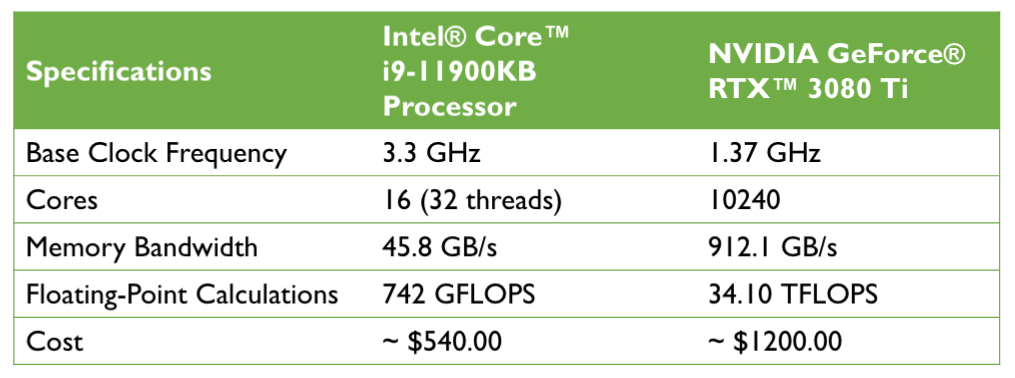

In [1]:
from IPython.display import Image as IPythonImage
IPythonImage(filename='figures/12_01.png', width=500)

#### 12.1.2. Что такое PyTorch? 

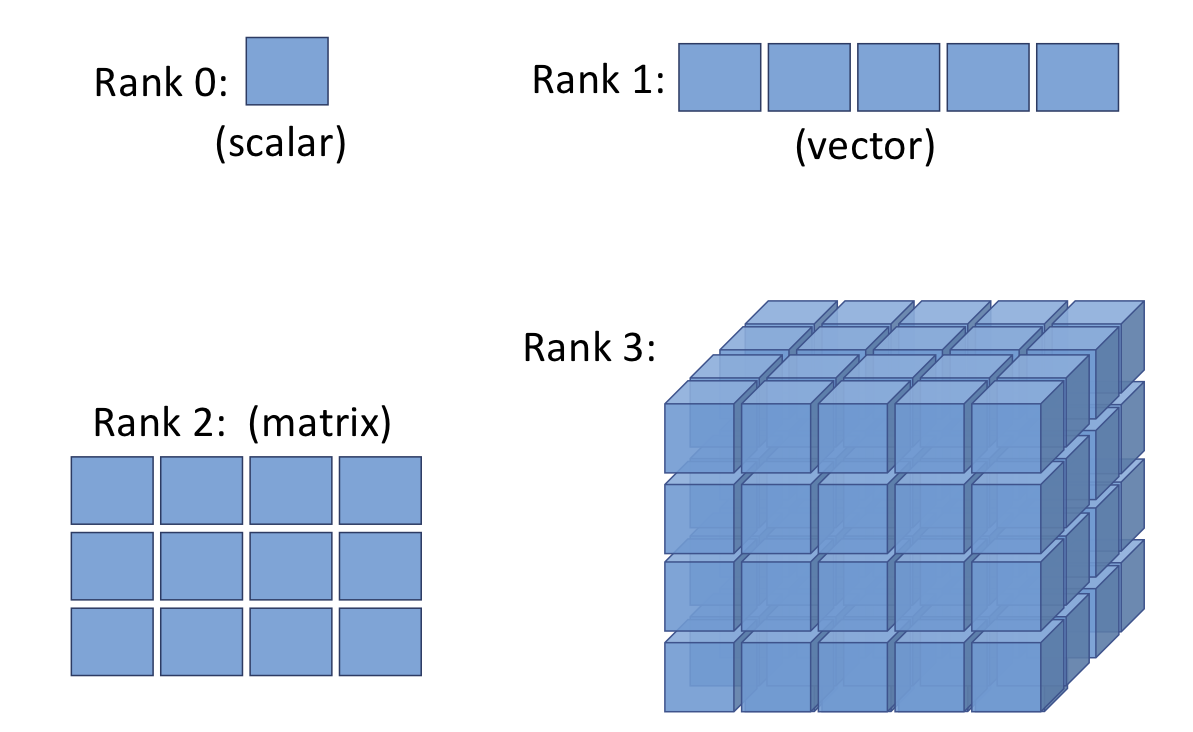

In [2]:
IPythonImage(filename='figures/12_02.png', width=500)

### 12.2. Первые шаги с PyTorch 

#### 12.2.1. Установка PyTorch 

In [3]:
import torch
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")
print(f"Версия CUDA в PyTorch: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"Имя GPU: {torch.cuda.get_device_name(0)}")
    print(f"Количество GPU: {torch.cuda.device_count()}")
    
    # Простой тест
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    y = torch.tensor([4.0, 5.0, 6.0]).cuda()
    print(f"Тест GPU: {x + y}")
else:
    print("❌ CUDA НЕ ДОСТУПНА")
    print("Проверьте драйверы NVIDIA и перезагрузите компьютер")

PyTorch версия: 2.12.0.dev20260408+cu128
CUDA доступна: True
Версия CUDA в PyTorch: 12.8
Имя GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Количество GPU: 1
Тест GPU: tensor([5., 7., 9.], device='cuda:0')


### 12.2.2. Создание тензоров в PyTorch 

В этом разделе мы изучим несколько различных способов создания тензоров, а затем рассмотрим некоторые их свойства и узнаем, как с ними обращаться. Мы можем создать тензор из простого списка или массива NumPy, используя функцию torch.tensor или torch. from_numpy:

In [4]:
import numpy as np
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)

print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


После запуска этого кода будут созданы тензоры t_a и t_b с их свойствами shape=(3,) и dtype=int32 в соответствии с источником данных тензора. Как и в случае массивов NumPy, мы можем посмотреть эти свойства: 

In [5]:
print(torch.is_tensor(a), torch.is_tensor(t_a))
t_ones = torch.ones(2, 3)
print(t_ones.shape)
print(t_ones)
rand_tensor = torch.rand(2,3)
print(rand_tensor)

False True
torch.Size([2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.9449, 0.0780, 0.3918],
        [0.7541, 0.9963, 0.8640]])


### 12.2.3. Управление типом данных и формой тензора 

Изучение способов управления тензорами необходимо, чтобы сделать их подходящими для ввода в модель или в операцию. В этом разделе вы узнаете, как управлять типами данных и формами тензоров с помощью нескольких функций PyTorch, которые выполняют операции преобразования, транспонирования и сжатия (удаления измерений). Функцию torch.to() можно использовать для изменения типа данных тензора на желаемый тип: 

In [6]:
t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


Как вы увидите в следующих главах, некоторые операции требуют, чтобы входные тензоры имели определенное количество измерений (т. е. ранг), связанных с определенным количеством элементов ( форма). Поэтому часто возникает необходимость изменить форму тензора, добавить новое измерение или удалить лишнее. Для этих целей PyTorch предоставляет полезные функции (или операции) - такие как torch.transpose(), torch.reshape() и torch.squeeze(). Давайте рассмотрим несколько примеров: 

In [7]:
# транспонирование тензора:
t = torch.rand(3, 5)
t_tr = torch.transpose(t, 0, 1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


In [8]:
# изменение формы тензора (например, преобразование из одномерного вектора в двумерный массив): 
t = torch.zeros(30)
t_reshape = t.reshape(5, 6)
print(t)
print(t_reshape)
print(t_reshape.shape)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
torch.Size([5, 6])


In [9]:
# удаление ненужных измерений (измерения с размером 1, которые не нужны): 
t = torch.zeros(1, 2, 1, 4, 1)
#print(t)
t_sqz = torch.squeeze(t, 2)
#print(t_sqz)
print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


### 12.2.4. Применение к тензорам математических операций 

При построении моделей машинного обучения не обойтись без математических процедур и, в частности, операций линейной алгебры. В этом разделе мы рассмотрим некоторые широко используемые операции линейной алгебры - такие как поэлементное произведение, умножение матриц и вычисление нормы тензора.
Мы начнем с создания двух случайных тензоров: одного с равномерным распределением в диапазоне [-1, 1), а другого - со стандартным нормальным распределением: 

In [10]:
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

Метод torch.rand возвращает тензор, заполненный случайными числами из равномерного распределения в диапазоне [0, 1).
Обратите внимание, что t1 и t2 имеют одинаковую форму. Далее, чтобы вычислить поэлементное произведение t1 и t2, выполним следующий код: 

In [11]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


Для вычисления среднего значения, суммы и стандартного отклонения по определенной оси (или осям) предназначены функции: torch.mean(), torch.sum() и torch.std(). Например, среднее значение каждого столбца в t1 можно вычислить следующим образом: 

In [12]:
t4 = torch.mean(t1, axis=0)
print(t4)

tensor([-0.1373,  0.2028])


Матричное произведение между t1 и t2 (т. е. t1 х $t2^T$, где индекс Т означает транспонирование) можно вычислить с помощью функции torch.matmul(): 

In [13]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


В свою очередь, вычисление произведения $t1^T$ х t2 выполняется путем транспонирования t1, в результате чего получается массив размером 2х2: 

In [14]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


Наконец, функция torch.linalg.norm() служит для вычисления $L^p$-нормы тензора. Например, мы можем вычислить $L^2$ -норму t1 следующим образом: 

In [15]:
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


Чтобы убедиться, что этот фрагмент кода правильно вычисляет норму $L^2$ для тензора t1, сравните результат со следующей функцией NumPy: 

In [16]:
np.sqrt(np.sum(np.square(t1.numpy()), axis=1))

array([0.67846215, 0.5078282 , 1.1162277 , 0.5487652 , 0.18525197],
      dtype=float32)

### 12.2.5. Разделение, стекирование и конкатенация тензоров 

В этом подразделе мы рассмотрим операции PyTorch по разделению тензора на несколько тензоров и, наоборот, стекирование и объединение нескольких тензоров в один. Предположим, что у нас есть один тензор и нужно разделить его на два или более тензоров. Для этого в PyTorch имеется удобная функция torch.chunk(), которая делит входной тензор на список тензоров одинакового размера. Целое число, заданное аргументом chunks, определяет количество фрагментов тензора по нужному измерению, заданному аргументом dim. В этом случае общий размер входного тензора по указанному измерению должен быть кратен желаемому количеству фрагментов. В качестве альтернативы можно указать желаемые размеры фрагментов в списке, используя функцию torch.split().
Далее представлены примеры кода для обоих этих вариантов: 

In [17]:
# заданное количество фрагментов: 
torch.manual_seed(1)
t = torch.rand(6)
print(t)
t_splits = torch.chunk(t, 3) 
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.7576316 , 0.27931088], dtype=float32),
 array([0.40306926, 0.73468447], dtype=float32),
 array([0.02928156, 0.7998586 ], dtype=float32)]

In [18]:
# список размеров различных фрагментов (в качестве альтернативы вместо определения количества фрагментов можно напрямую указать размеры выходных 
# тензоров. Здесь мы разбиваем тензор размером 5 на тензоры размером 3 и 2): 
torch.manual_seed(1)
t = torch.rand(5)
print(t)
t_splits = torch.split(t, split_size_or_sections=[3, 2])
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.7576316 , 0.27931088, 0.40306926], dtype=float32),
 array([0.73468447, 0.02928156], dtype=float32)]

Иногда мы работаем с несколькими тензорами, и нам нужно объединить или сложить их в стек, чтобы создать один тензор. В этом случае пригодятся такие функции PyTorch, как torch.stack() и torch.cat(). Для примера создадим одномерный тензор А размером 3, содержащий единицы, и одномерный тензор в размером 2, содержащий нули, и выполним их конкатенацию (объединение) в одномерный тензор с размером 5: 

In [19]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


Если взять одномерные тензоры А и B, оба размером з, то можно выполнить стекирование (своего рода укладку их «штабелем»), чтобы сформировать двумерный тензор s: 

In [20]:
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


Полный список операций и функций можно найти на странице документации PyTorch по адресу: https://pytorch.org/docs/staЫe/index.html. 

### 12.3. Построение конвейеров ввода в PyTorch 

Занимаясь обучением глубокой нейросетевой модели, мы обычно делаем это постепенно, используя итеративный алгоритм оптимизации - такой как стохастический градиентный спуск, что было показано в предыдущих главах. Как упоминалось в начале этой главы, torch.nn - это модуль для построения нейросетевых моделей. В тех случаях, когда обучающий набор данных достаточно мал и умещается в память в виде тензора, мы можем напрямую использовать этот тензор для обучения. Однако в большинстве типовых сценариев набор данных слишком велик, чтобы поместиться в память компьютера, и нам потребуется загружать данные с внешнего запоминающего устройства (например, с жесткого диска или твердотельного накопителя) фрагментами, т. е. пакет за пакетом. (Обратите внимание, что в этой главе мы используем термин «пакет» вместо «мини-пакет», чтобы соответствовать терминологии PyTorch.) 

Кроме того, иногда необходимо построить конвейер для предварительной обработки входных данных и выполнения определенных преобразований - таких как центрирование среднего значения, масштабирование или добавление шума, чтобы расширить процедуру обучения и предотвратить переобучение.
Было бы довольно неудобно регулярно организовывать цепочку функций предварительной обработки вручную. К счастью, PyTorch предоставляет специальный класс для создания эффективных и удобных конвейеров предварительной обработки. В этом разделе мы представим обзор различных методов создания объектов PyTorch dataset и DataLoacter, а также реализации загрузки, перетасовки и пакетной обработки данных. 

### 12.3.1. Создание объекта DataLoader из существующих тензоров 

Если данные уже существуют в виде тензорного объекта, списка Python или массива NumPy, мы можем легко создать загрузчик набора данных с помощью класса
torch.utils.data.DataLoader(). Он возвращает объект класса DataLoader, который можно использовать для перебора отдельных элементов во входном наборе данных. В качестве простого примера рассмотрим следующий код, который создает набор данных из списка значений от 0 до 5:

In [21]:
from torch.utils.data import DataLoader
t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)
print(t)
for item in data_loader:
    print(item)

tensor([0., 1., 2., 3., 4., 5.])
tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


Допустим, нам нужно создать из этого набора данных пакеты размером 3. Воспользуемся аргументом batch_size в следующем коде: 

In [22]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)
for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


Этот код создает из текущего набора данных два пакета, где первые три элемента перейдут в пакет #1, а остальные элементы - в пакет #2. Необязательный аргумент drop_last полезен в случаях, когда количество элементов в тензоре не кратно желаемому размеру пакета. Мы можем удалить последний неполный пакет, установив для drop_last значение True (по умолчанию для drop_last установлено значение False).
Мы всегда можем выполнить итеративную обработку набора данных напрямую, но, как вы только что видели, DataLoader обеспечивает автоматическую и настраиваемую пакетную обработку набора данных. 

### 12.3.2. Объединение двух тензоров в совместный набор данных 

Часто бывает так, что данные хранятся в двух (или более) тензорах. Например, у нас может быть тензор для признаков и тензор для меток. В таких случаях нужно построить набор данных, объединяющий эти тензоры, что позволит извлекать элементы тензоров в кортежах. Предположим, что у нас есть два тензора: t_x и t_y. Тензор t_x содержит значения признаков, каждое размером 3, а тензор t_У хранит метки классов. Для примера мы сначала создадим эти два тензора: 

In [23]:
torch.manual_seed(1)
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)
print(t_x)
print(t_y)

tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999],
        [0.3971, 0.7544, 0.5695],
        [0.4388, 0.6387, 0.5247]])
tensor([0, 1, 2, 3])


Теперь мы должны сформировать совместный набор данных из этих двух тензоров. Сперва мы создадим класс Dataset:

In [24]:
from torch.utils.data import Dataset
class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

Пользовательский класс dataset должен содержать методы, которые впоследствии будет использовать загрузчик данных dataLoader:\
♦ __init__() : - здесь выполняется вся предварительная работа, такая как чтение cуществующих массивов, загрузка файла, фильтрация данных и т. д.;\
♦ __getitem__(): -возвращает соответствующий образец по заданному индексу.\
Затем мы создаем совместный набор данных t_х и t_У с помощью пользовательского класса dataset: 

In [25]:
joint_dataset = JointDataset(t_x, t_y)

from torch.utils.data import TensorDataset
joint_dataset = TensorDataset(t_x, t_y)

for example in joint_dataset:
    print('  x: ', example[0], 
          '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


### 12.3.3. Перемешивание, группировка и повторение 

Как отмечалось в главе 2, при обучении нейросетевой модели с использованием оптимизации методом стохастического градиентного спуска важно подавать обучающие данные в виде случайно перемешанных пакетов. Вы уже знаете, как указать размер пакета с помощью аргумента batch_size объекта загрузчика данных. Далее вы узнаете, как перетасовывать и повторять наборы данных (мы продолжим работу с полученным ранее объединенным набором данных).
Для начала создадим перемешивающую версию загрузчика данных из набора joint_dataset: 

In [26]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

Здесь каждый пакет содержит две записи данных (х) и соответствующие метки (у). Затем мы перебираем записи загрузчика данных одну за другой: 

In [27]:
for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])


Строки перемешиваются без потери однозначного соответствия между элементами х и у. Кроме того, при обучении модели в течение нескольких эпох нам нужно перетасовать и перебрать набор данных для желаемого количества эпох. Итак, давайте дважды выполним перебор пакетного набора данных: 

In [28]:
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])


Выполнение этого кода дает нам два различных набора пакетов. В первой эпохе первый пакет содержит пару значений [y=l, у=2], а второй пакет - пару значений [у=3, y=0]. Во второй эпохе два пакета содержат пары значений [у=2, y=O] и [y=l, y=3] соответственно.
Для каждой итерации элементы в пакете также перемешиваются. 

#### 12.3.4. Создание набора данных из файлов на локальном диске 

PIL.Image - для чтения содержимого файла изображения и torchvision.transforms - для декодирования необработанного содержимого и изменения размера изображений. 
Прежде чем двигаться дальше, давайте посмотрим на содержимое этих файлов, воспользовавшись библиотекой pathlib для создания списка файлов изображений: 

In [29]:
import pathlib
imgdir_path = pathlib.Path('cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Затем отобразим на экране эти примеры изображений с помощью Matplotlib (рис. 12.3): 

Paзмepы изображения:  (900, 1200, 3)
Paзмepы изображения:  (900, 1200, 3)
Paзмepы изображения:  (900, 742, 3)
Paзмepы изображения:  (800, 1200, 3)
Paзмepы изображения:  (800, 1200, 3)
Paзмepы изображения:  (900, 1200, 3)


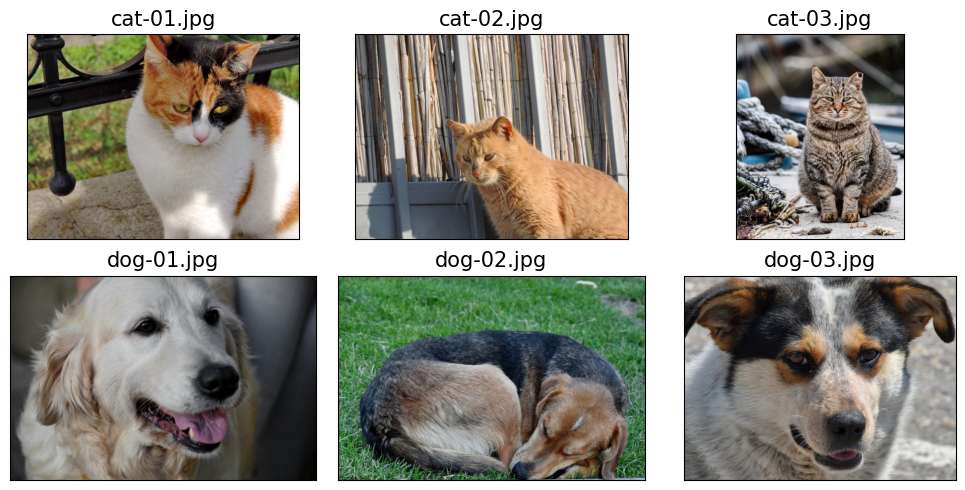

In [30]:
import matplotlib.pyplot as plt
import os
from PIL import Image

fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Paзмepы изображения: ', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)
plt.tight_layout()
plt.show()

Легко заметить, что изображения имеют разные пропорции. Если вы выведите соотношения сторон (или формы массива данных) этих изображений, то увидите, что некоторые изображения имеют 900 пикселов в высоту и 1200 пикселов в ширину (9ООх1200), некоторые - 8ООх1200, а одно - 9ООх742. Позже мы выполним предварительную обработку и приведем эти изображения к одинаковому размеру. Еще один момент, который следует учитывать, заключается в том , что метками для этих изображений являются имена их файлов. Поэтому мы извлекаем эти метки из списка имен файлов, присваивая метку 1 собакам и метку о кошкам: 

In [31]:
labels = [1 if 'dog' in os.path.basename(file) else 0
          for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


Теперь у нас есть два списка: список имен файлов (или путей к каждому изображению) и список их меток. В предыдущем разделе вы узнали, как создать совместный набор данных из двух массивов. Здесь мы поступим аналогичным образом: 

In [32]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]      
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)
    
image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


Объединенный набор данных содержит имена файлов и метки. Затем к этому набору данных нужно применить следующие операции: загрузить содержимое изображения по его пути к файлу, декодировать необработанное содержимое и изменить его размер до желаемого значения - например, 8Ох120. Воспользуемся
модулем torchvision.transfoпns для изменения размера изображений и преобразования загруженных пикселов в тензоры:     

In [33]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([transforms.ToTensor(),transforms.Resize((img_height, img_width)),])

Теперь обновим класс ImageDataset с помощью только что определенного метода transform: 

In [34]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    def __getitem__(self, index):
        img = Image.open(self.file_list[index])        
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    def __len__(self):
        return len(self.labels) 
image_dataset = ImageDataset(file_list, labels, transform)

Наконец, отобразим преобразованные изображения с помощью Matplotlib: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


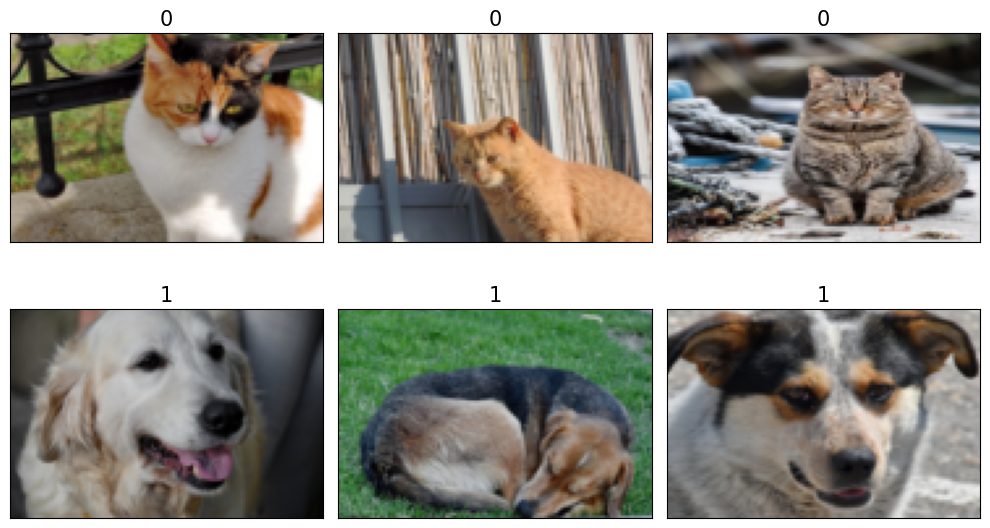

In [ ]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)
    
plt.tight_layout()
plt.show()

Метод getitem в классе ImageDataset объединяет все четыре шага в одну функцию, включая загрузку необработанного содержимого (изображений и меток), декодирование изображений в тензоры и изменение размера изображений. Затем функция возвращает набор данных, к которому можно применять с помощью загрузчика данных другие операции, известные вам из предыдущих разделов, такие как перемешивание и пакетная обработка. 

#### 12.3.5. Получение доступных наборов данных из библиотеки torchvision.datasets 

Библиотека (модуль) torchvision.datasets содержит хорошую коллекцию свободно доступных наборов данных изображений для обучения или оценки моделей глубокого обучения. Аналогичным образом библиотека torchtext. datasets предоставляет наборы данных для моделей естественного языка. В этой главе в качестве примера мы используем модуль torchvision.datasets. 

Наборы данных torchvision (https://pytorch.org/vision/staЫe/datasets.html) хорошо отформатированы и снабжены информативными описаниями, включающими формат признаков и меток, их тип и размерность, а также ссылку на оригинальный источник набора данных. Еще одним преимуществом является то, что все эти наборы данных являются подклассами torch.utils.data.Dataset, поэтому все функции, рассмотренные в предыдущих разделах, можно применять напрямую. Итак, давайте попробуем использовать эти наборы данных на практике. 

In [ ]:
# ! pip install torchvision
# Со списком доступных наборов данных вы можете ознакомиться по адресу:
# https://pytorch.org/vision/stable/datasets.html. 

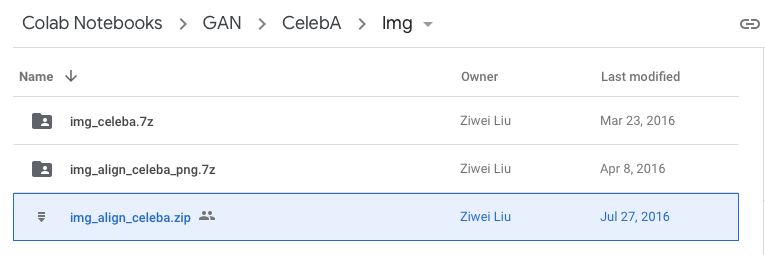

In [37]:
IPythonImage(filename='figures/gdrive-download-location-1.png', width=500)

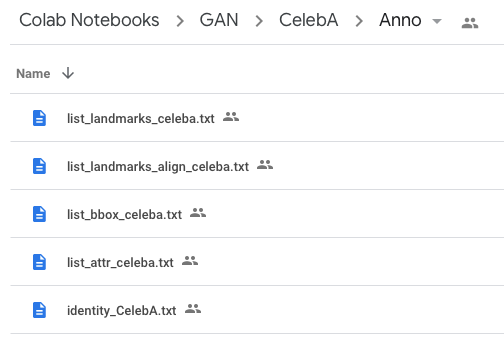

In [38]:
IPythonImage(filename='figures/gdrive-download-location-2.png', width=300)

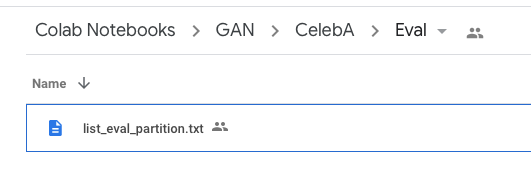

In [39]:
IPythonImage(filename='figures/gdrive-download-location-3.png', width=300)

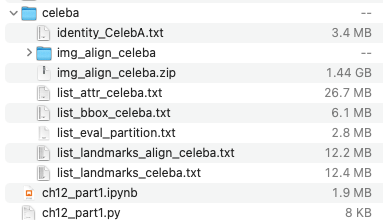

In [40]:
IPythonImage(filename='figures/celeba-files.png', width=400)

Далее мы рассмотрим получение двух разных наборов данных: CelebA (celeb_а) и набора цифровых данных МNIST. Давайте сначала поработаем с набором данных CelebA, представленным в виде объекта torchvision.datasets.CelebA. Его описание содержит полезную информацию, которая поможет нам понять структуру этого набора данных:\
♦ база данных имеет три подмножества: 'train', 'valid' и 'test'. Мы можем выбрать конкретное подмножество или загрузить их все с параметром split;\
♦ изображения сохраняются в формате PIL.Image. Мы можем получить преобразованную версию, используя пользовательскую функцию transfonn, такую как transfonns.ToTensor и transfonns.Resize;\
♦ существуют различные типы целей, которые мы можем использовать, включая 'attributes ', 'identity' и 'landmarks'. Тип 'attributes' - это 40 атрибутов лица человека на изображении (выражение лица, макияж, свойства волос и т. п.); 'ictentity' -
это идентификатор человека для изображения, а 'landmarks' относится к словарю извлеченных точек лица (положение глаз, носа и т. п.).\
Затем мы вызываем класс torchvision.datasets.celebA для загрузки данных, сохранения их на диске в указанной папке и загрузки в объект torch. utils. ctata. Dataset: 

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import torch
import os

class CelebADataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        root_dir: папка, содержащая img_align_celeba/, list_attr_celeba.txt, list_eval_partition.txt
        split: 'train', 'valid', 'test'
        """
        self.root_dir = root_dir
        self.transform = transform
        self.img_dir = os.path.join(root_dir, 'img_align_celeba')
        
        # Читаем файл разбиения (используем raw-строку или двойной слеш)
        partition_file = os.path.join(root_dir, 'list_eval_partition.txt')
        self.partition = pd.read_csv(partition_file, sep=r'\s+', header=None,  # raw-строка
                                      names=['filename', 'partition'])
        
        # Читаем файл атрибутов
        attr_file = os.path.join(root_dir, 'list_attr_celeba.txt')
        
        # Первая строка - количество атрибутов, вторая - заголовки
        with open(attr_file, 'r') as f:
            lines = f.readlines()
            num_attrs = int(lines[0].strip())
            attr_names = lines[1].strip().split()
        
        # Читаем данные атрибутов (используем raw-строку)
        self.attributes = pd.read_csv(attr_file, sep=r'\s+', skiprows=2, 
                                       header=None, names=['filename'] + attr_names)
        
        # Преобразуем атрибуты из -1,1 в 0,1
        for attr in attr_names:
            self.attributes[attr] = (self.attributes[attr] + 1) // 2
        
        # Объединяем разбиение и атрибуты
        self.data = pd.merge(self.partition, self.attributes, on='filename')
        
        # Фильтруем по split
        split_map = {'train': 0, 'valid': 1, 'test': 2}
        self.data = self.data[self.data['partition'] == split_map[split]]
        
        print(f"Загружено {len(self.data)} изображений для split='{split}'")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        
        # Загружаем изображение
        image = Image.open(img_path)
        
        if self.transform:
            image = self.transform(image)
        
        # Загружаем атрибуты (все атрибуты кроме filename и partition)
        attr_columns = [col for col in self.data.columns if col not in ['filename', 'partition']]
        attributes = torch.tensor(row[attr_columns].values.astype('float32'))
        
        return image, attributes

# Использование
celeba_dataset = CelebADataset(
    root_dir='./celeba',  # ваша папка с данными
    split='train',
    transform=None  # можно добавить transforms.Compose([...])
)

print(f"Размер датасета: {len(celeba_dataset)}")
# Проверка
if len(celeba_dataset) > 0:
    image, attrs = celeba_dataset[0]
    print(f"Форма изображения: {image.size}")
    print(f"Количество атрибутов: {len(attrs)}")
    print(f"Первые 5 атрибутов: {attrs[:5]}")

Загружено 162770 изображений для split='train'
Размер датасета: 162770
Форма изображения: (178, 218)
Количество атрибутов: 40
Первые 5 атрибутов: tensor([0., 1., 1., 0., 0.])


Создав экземпляры наборов данных, нужно удостовериться, относится ли объект к классу torch.utils.data.Dataset: 

In [62]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

Как мы упоминали ранее, набор данных уже разделен на сегменты данных для обучения, тестирования и валидации, и мы загружаем только обучающий набор. Кроме того, мы используем только цель 'attributes'. Чтобы увидеть, как выглядят примеры данных, выполните следующий код: 

In [63]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x177D360FC50>, tensor([0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
        1., 0., 0., 1.]))


Обратите внимание, что обучающий пример в этом наборе данных представляет собой кортеж вида (PIL.Image, attributes). Если мы хотим передать этот набор данных в модель глубокого обучения во время обучения с учителем, нам нужно переформатировать его как кортеж (features tensor, label). Для метки мы будем использовать в качестве примера категорию 'Smiling' (улыбающиеся), которая является 31-м элементом. Наконец, возьмем из набора первые 18 примеров и отобразим их на экране вместе со значениями соответствующих меток 'Smiling' (рис. 12.5): 

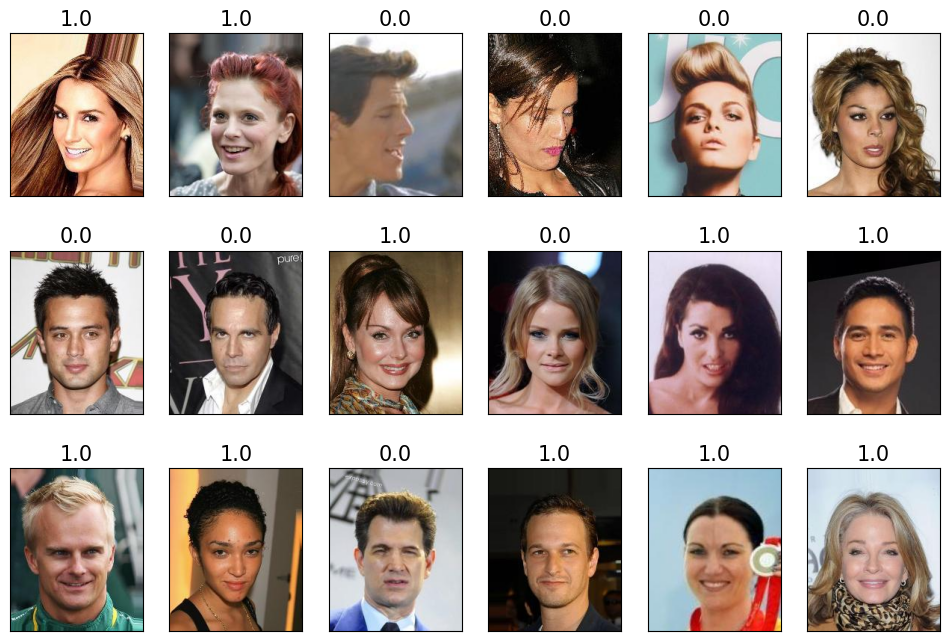

In [64]:
from itertools import islice
fig = plt.figure(figsize=(12, 8))
for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size=15)
plt.show()

Теперь перейдем ко второму набору данных из torchvision.ctatasets.MNIST (https://pytorch.org/vision/staЫe/datasets.html#mnist). Давайте посмотрим, как его можно использовать для получения набора данных МNIST:\
♦ база данных состоит из двух разделов: 'train' и 'test'. Нужно выбрать конкретное подмножество для загрузки;\
♦ изображения сохраняются в формате PIL. Image. Можно получить преобразованную версию, используя пользовательскую функцию transform., такую как transforms.ToTensor И transforms.Resize;\
♦ существуют 10 классов изображений- от 0 до 9. 

При помощи следующего кода мы загрузим раздел 'train', преобразуем элементы в кортежи и отобразим 1О извлеченных примеров рукописных цифр из этого набора данных (рис. 12.6): 

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 177kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 19.4MB/s]


(<PIL.Image.Image image mode=L size=28x28 at 0x177D84A87D0>, 5)


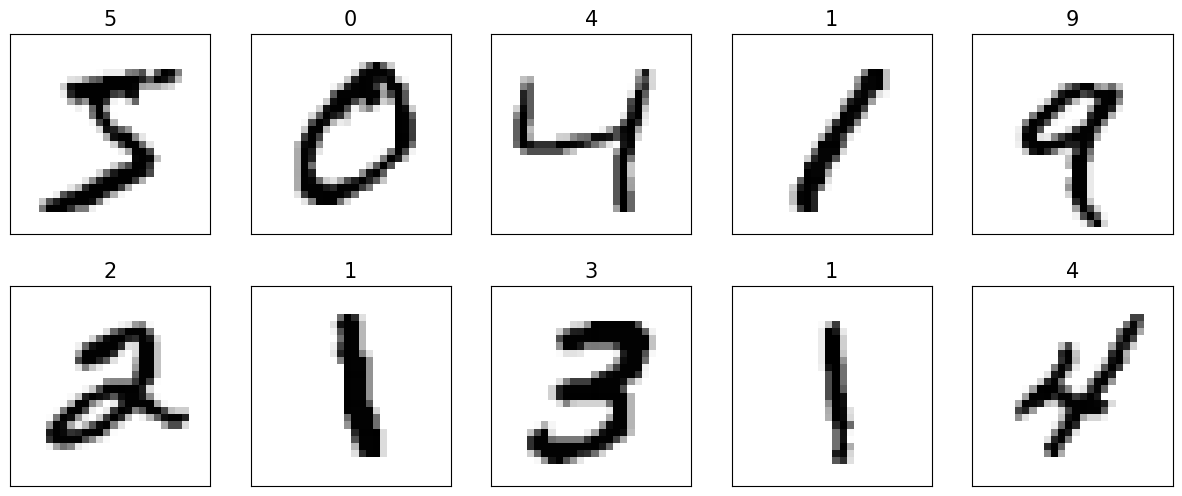

In [ ]:
import torchvision
image_path = './'  
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=True)

assert isinstance(mnist_dataset, torch.utils.data.Dataset)

example = next(iter(mnist_dataset))
print(example)

fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)
plt.show()

На этом мы завершаем изучение способов создания наборов данных и управления ими, а также извлечения наборов данных из библиотеки torchvision.datasets и переходим |к созданию нейросетевых моделей в PyTorch. 